In [164]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy.fft import fft, fftfreq

H5_PATH   = r"../data/processed/ims_data.h5"
TEST      = "2nd_test"
BEARING   = "B1"
FS        = 20480

In [142]:
with h5py.File(H5_PATH, "r") as f:
    grp       = f[f"{TEST}/{BEARING}"]
    signals    = grp["signals"][:]        # (984, 20480, 1)
    timestamps = grp["timestamps"][:]     # (984,)
    n_snapshots = grp.attrs["n_snapshots"]

print(f"signals shape : {signals.shape}")
print(f"n_snapshots   : {n_snapshots}")
print(f"first file    : {timestamps[0]}")
print(f"last file     : {timestamps[-1]}")

signals shape : (984, 20480, 1)
n_snapshots   : 984
first file    : b'2004.02.12.10.32.39'
last file     : b'2004.02.19.06.22.39'


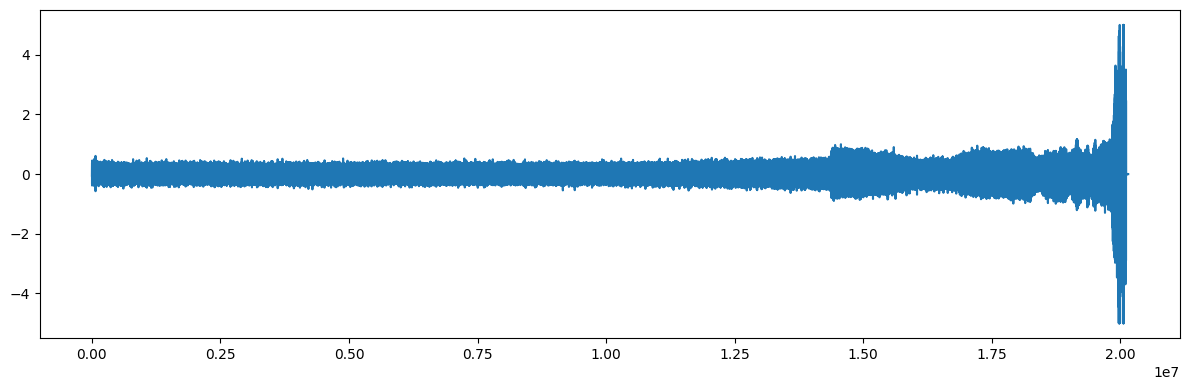

In [158]:
#plot the entire signal 
plt.figure(figsize=(12, 4))
plt.plot(signals[:, :].flat)
plt.tight_layout()
# plt.savefig("results/01_raw_signal_comparison.png", dpi=150)
plt.show()

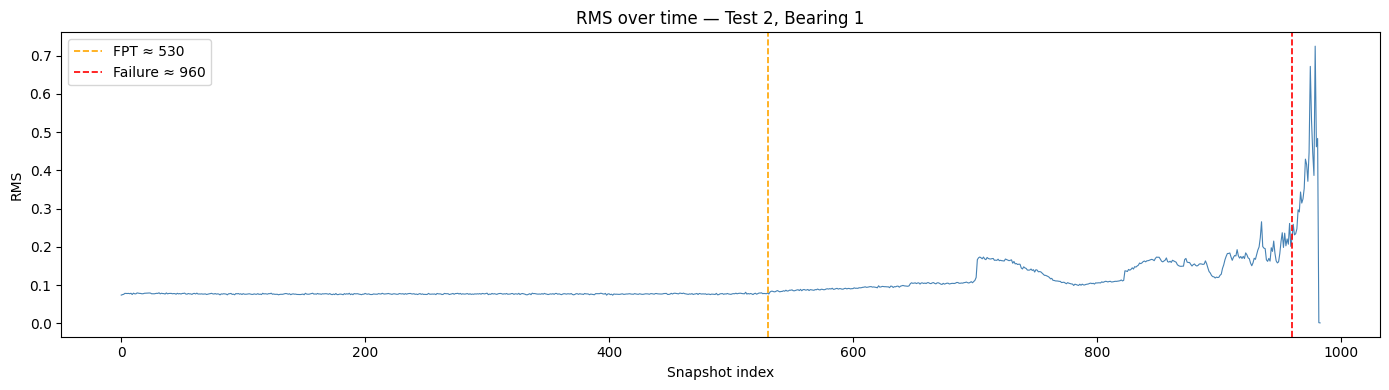

In [159]:
rms = np.sqrt(np.mean(signals[:, :, 0] ** 2, axis=1))

plt.figure(figsize=(14, 4))
plt.plot(rms, linewidth=0.8, color="steelblue")
plt.axvline(x=530, color="orange", linewidth=1.2, linestyle="--", label="FPT ≈ 530")
plt.axvline(x=960, color="red",    linewidth=1.2, linestyle="--", label="Failure ≈ 960")
plt.title("RMS over time — Test 2, Bearing 1")
plt.xlabel("Snapshot index")
plt.ylabel("RMS")
plt.legend()
plt.tight_layout()
plt.show()

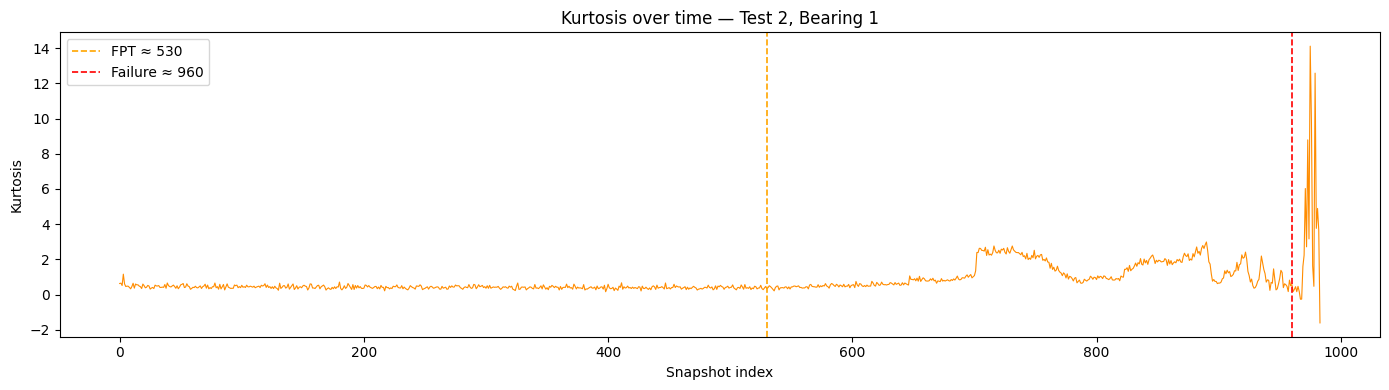

In [160]:
from scipy.stats import kurtosis

# compute kurtosis for every snapshot
kurt = np.array([kurtosis(signals[i, :, 0], fisher=True) for i in range(len(signals))])

plt.figure(figsize=(14, 4))
plt.plot(kurt, linewidth=0.8, color="darkorange")
plt.axvline(x=530, color="orange", linewidth=1.2, linestyle="--", label="FPT ≈ 530")
plt.axvline(x=960, color="red",    linewidth=1.2, linestyle="--", label="Failure ≈ 960")
plt.title("Kurtosis over time — Test 2, Bearing 1")
plt.xlabel("Snapshot index")
plt.ylabel("Kurtosis")
plt.legend()
plt.tight_layout()
plt.show()

In [161]:
D        = 2.815
d        = 0.331
n        = 16
alpha    = np.radians(15.17)
shaft_hz = 2000 / 60

ratio = (d / D) * np.cos(alpha)

FTF  = (shaft_hz / 2) * (1 - ratio)
BPFO = (n / 2) * shaft_hz * (1 - ratio)
BPFI = (n / 2) * shaft_hz * (1 + ratio)
BSF  = (D / (2 * d)) * shaft_hz * (1 - ratio**2)

print(f"Shaft speed : {shaft_hz:.4f} Hz")
print(f"FTF         : {FTF:.2f} Hz")
print(f"BPFO        : {BPFO:.2f} Hz  ← outer race fault (our bearing)")
print(f"BPFI        : {BPFI:.2f} Hz")
print(f"BSF         : {BSF:.2f} Hz")

Shaft speed : 33.3333 Hz
FTF         : 14.78 Hz
BPFO        : 236.40 Hz  ← outer race fault (our bearing)
BPFI        : 296.93 Hz
BSF         : 139.92 Hz


In [165]:
def compute_fft(signal, fs):
    N     = len(signal)
    freqs = fftfreq(N, d=1/fs)[:N//2]
    mag   = np.abs(fft(signal))[:N//2]
    return freqs, mag

early = signals[0,   :, 0]
late  = signals[900, :, 0]

freqs_e, mag_e = compute_fft(early, FS)
freqs_l, mag_l = compute_fft(late,  FS)

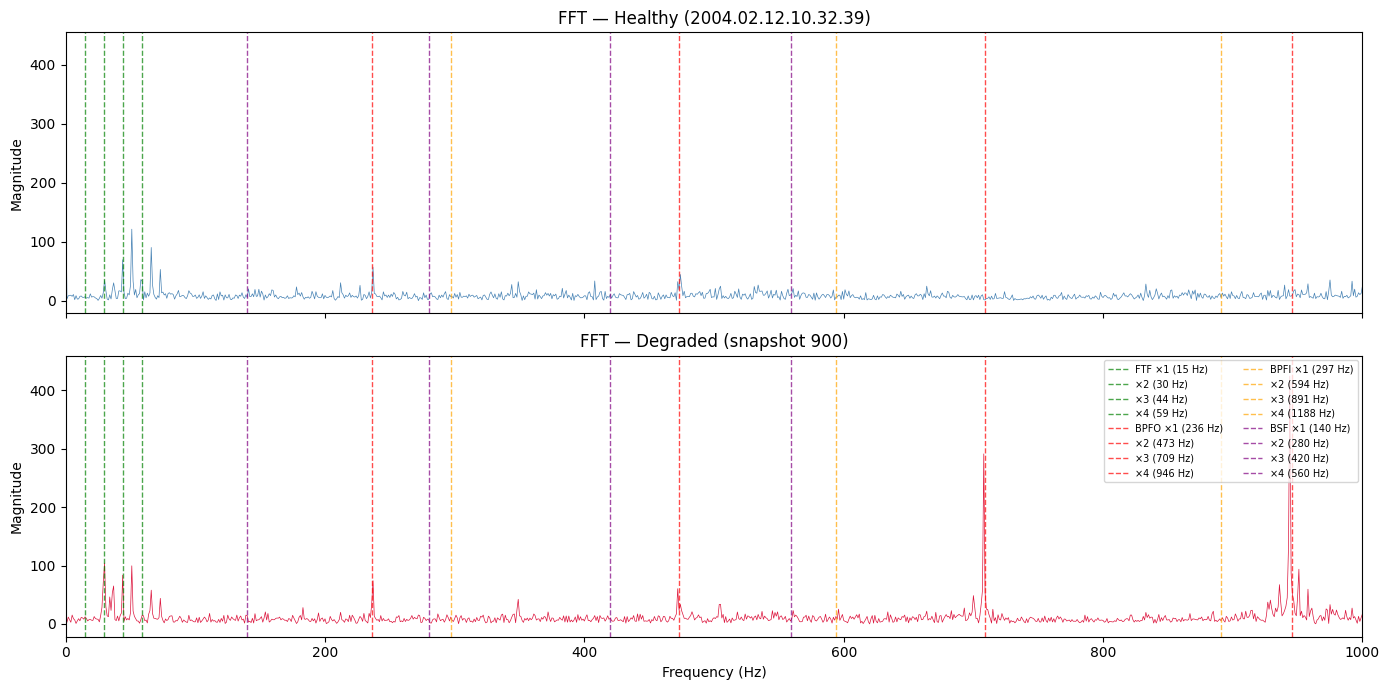

In [166]:
fault_freqs = {
    "FTF" : {"freq": FTF,  "color": "green"},
    "BPFO": {"freq": BPFO, "color": "red"},
    "BPFI": {"freq": BPFI, "color": "orange"},
    "BSF" : {"freq": BSF,  "color": "purple"},
}

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(freqs_e, mag_e, linewidth=0.5, color="steelblue")
axes[0].set_title(f"FFT — Healthy ({timestamps[0].decode('utf-8')})")
axes[0].set_ylabel("Magnitude")

axes[1].plot(freqs_l, mag_l, linewidth=0.5, color="crimson")
axes[1].set_title("FFT — Degraded (snapshot 900)")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlabel("Frequency (Hz)")

for name, info in fault_freqs.items():
    for i in range(1, 5):
        h     = info["freq"] * i
        label = f"{name} ×{i} ({h:.0f} Hz)" if i == 1 else f"×{i} ({h:.0f} Hz)"
        for ax in axes:
            ax.axvline(x=h, color=info["color"], linewidth=1,
                       linestyle="--", alpha=0.7,
                       label=label if ax == axes[1] else "")

axes[1].legend(loc="upper right", fontsize=7, ncol=2)
axes[1].set_xlim(0, 1000)
axes[0].set_xlim(0, 1000)
plt.tight_layout()
plt.show()

## EDA Findings — Test 2, Bearing 1 (Outer Race Fault)

| Finding                        | Value / observation                          |
|-------------------------------|----------------------------------------------|
| Total snapshots               | 984                                          |
| Sampling frequency            | 20480 Hz                                     |
| Run duration                  | 2004.02.12 → 2004.02.19 (7 days)            |
| FPT (First Prediction Time)   | ≈ snapshot 530                               |
| Failure point                 | ≈ snapshot 960                               |
| Post-failure snapshots        | 960–983 (to be trimmed before RUL labeling)  |
| BPFO                          | 236.4 Hz — confirmed by FFT harmonics        |
| Key feature insight           | Energy at BPFO harmonics grows with fault    |
| RMS                           | Rises sharply after snapshot 800             |
| Kurtosis                      | Sensitive to early fault, saturates at ~960  |

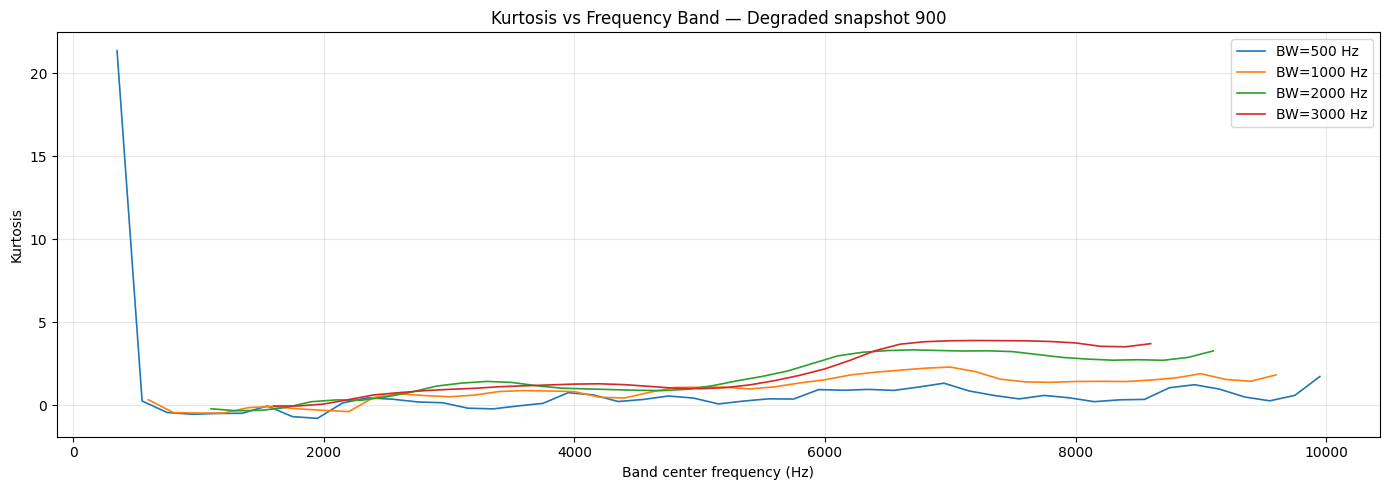


Optimal band:
  Start     : 100 Hz
  End       : 600 Hz
  Center    : 350 Hz
  Bandwidth : 500 Hz
  Kurtosis  : 21.3714


In [174]:
from scipy.signal import butter, filtfilt

def bandpass_rms_kurt(signal, lowcut, highcut, fs):
    """Bandpass filter signal and return kurtosis of the filtered signal."""
    nyq  = fs / 2
    # skip if band is invalid
    if lowcut <= 0 or highcut >= nyq or lowcut >= highcut:
        return 0
    b, a = butter(4, [lowcut/nyq, highcut/nyq], btype="band")
    filtered = filtfilt(b, a, signal)
    return kurtosis(filtered, fisher=True)

# use a degraded snapshot (snapshot 900)
sig = signals[900, :, 0]
nyq = FS / 2

# define frequency bands to sweep
# vary both center frequency and bandwidth
band_starts = np.arange(100, int(nyq), 200)    # sweep start from 100 to 10000 Hz
bandwidths  = [500, 1000, 2000, 3000]           # try different bandwidths

results = []
for bw in bandwidths:
    for f_start in band_starts:
        f_end = f_start + bw
        if f_end > nyq:
            break
        kurt_val = bandpass_rms_kurt(sig, f_start, f_end, FS)
        results.append({
            "f_start": f_start,
            "f_center": (f_start + f_end) / 2,
            "bandwidth": bw,
            "kurtosis": kurt_val
        })

import pandas as pd
df = pd.DataFrame(results)

# plot kurtosis vs center frequency for each bandwidth
plt.figure(figsize=(14, 5))
for bw in bandwidths:
    subset = df[df["bandwidth"] == bw]
    plt.plot(subset["f_center"], subset["kurtosis"],
             linewidth=1.2, label=f"BW={bw} Hz")

plt.title("Kurtosis vs Frequency Band — Degraded snapshot 900")
plt.xlabel("Band center frequency (Hz)")
plt.ylabel("Kurtosis")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# print the best band
best = df.loc[df["kurtosis"].idxmax()]
print(f"\nOptimal band:")
print(f"  Start     : {best['f_start']:.0f} Hz")
print(f"  End       : {best['f_start'] + best['bandwidth']:.0f} Hz")
print(f"  Center    : {best['f_center']:.0f} Hz")
print(f"  Bandwidth : {best['bandwidth']:.0f} Hz")
print(f"  Kurtosis  : {best['kurtosis']:.4f}")

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_rms_kurt(signal, lowcut, highcut, fs):
    """Bandpass filter signal and return kurtosis of the filtered signal."""
    nyq  = fs / 2
    # skip if band is invalid
    if lowcut <= 0 or highcut >= nyq or lowcut >= highcut:
        return 0
    b, a = butter(4, [lowcut/nyq, highcut/nyq], btype="band")
    filtered = filtfilt(b, a, signal)
    return kurtosis(filtered, fisher=True)

# use a degraded snapshot (snapshot 900)
sig = signals[900, :, 0]
nyq = FS / 2

# define frequency bands to sweep
# vary both center frequency and bandwidth
band_starts = np.arange(100, int(nyq), 200)    # sweep start from 100 to 10000 Hz
bandwidths  = [500, 1000, 2000, 3000]           # try different bandwidths

results = []
for bw in bandwidths:
    for f_start in band_starts:
        f_end = f_start + bw
        if f_end > nyq:
            break
        kurt_val = bandpass_rms_kurt(sig, f_start, f_end, FS)
        results.append({
            "f_start": f_start,
            "f_center": (f_start + f_end) / 2,
            "bandwidth": bw,
            "kurtosis": kurt_val
        })

import pandas as pd
df = pd.DataFrame(results)

# plot kurtosis vs center frequency for each bandwidth
plt.figure(figsize=(14, 5))
for bw in bandwidths:
    subset = df[df["bandwidth"] == bw]
    plt.plot(subset["f_center"], subset["kurtosis"],
             linewidth=1.2, label=f"BW={bw} Hz")

plt.title("Kurtosis vs Frequency Band — Degraded snapshot 900")
plt.xlabel("Band center frequency (Hz)")
plt.ylabel("Kurtosis")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# print the best band
best = df.loc[df["kurtosis"].idxmax()]
print(f"\nOptimal band:")
print(f"  Start     : {best['f_start']:.0f} Hz")
print(f"  End       : {best['f_start'] + best['bandwidth']:.0f} Hz")
print(f"  Center    : {best['f_center']:.0f} Hz")
print(f"  Bandwidth : {best['bandwidth']:.0f} Hz")
print(f"  Kurtosis  : {best['kurtosis']:.4f}")

In [167]:
from scipy.signal import butter, filtfilt
from scipy.signal import hilbert

def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    nyq  = fs / 2
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)

def compute_envelope(signal, fs, lowcut=2000, highcut=5000):
    # step 1 — bandpass filter around resonance band
    filtered = bandpass_filter(signal, lowcut, highcut, fs)
    
    # step 2 — hilbert transform → analytic signal
    analytic = hilbert(filtered)
    
    # step 3 — envelope = magnitude of analytic signal
    envelope = np.abs(analytic)
    
    # step 4 — squared envelope
    squared_envelope = envelope ** 2
    
    return filtered, envelope, squared_envelope

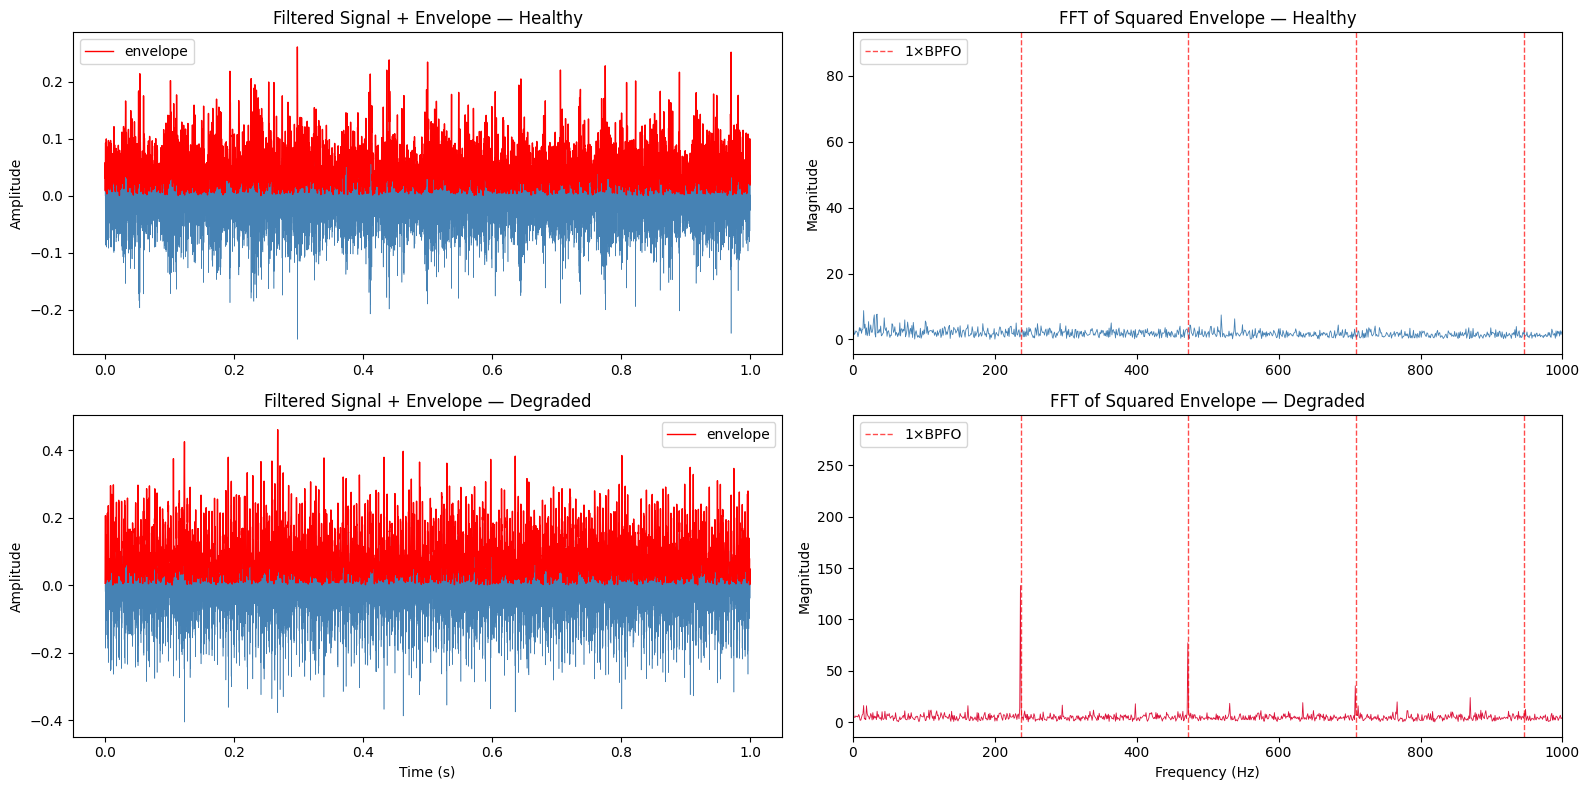

In [172]:
N_SAMPLES = signals.shape[1]
early = signals[0,   :, 0]
late  = signals[900, :, 0]

filt_e, env_e, sq_env_e = compute_envelope(early, FS)
filt_l, env_l, sq_env_l = compute_envelope(late,  FS)

time_axis = np.arange(N_SAMPLES) / FS

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# filtered signals
axes[0, 0].plot(time_axis, filt_e, linewidth=0.4, color="steelblue")
axes[0, 0].plot(time_axis, env_e,  linewidth=1.0, color="red", label="envelope")
axes[0, 0].set_title("Filtered Signal + Envelope — Healthy")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].legend()

axes[1, 0].plot(time_axis, filt_l, linewidth=0.4, color="steelblue")
axes[1, 0].plot(time_axis, env_l,  linewidth=1.0, color="red", label="envelope")
axes[1, 0].set_title("Filtered Signal + Envelope — Degraded")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].legend()

# FFT of squared envelope
freqs_se_e, mag_se_e = compute_fft(sq_env_e, FS)
freqs_se_l, mag_se_l = compute_fft(sq_env_l, FS)

axes[0, 1].plot(freqs_se_e, mag_se_e, linewidth=0.6, color="steelblue")
axes[0, 1].set_title("FFT of Squared Envelope — Healthy")
axes[0, 1].set_ylabel("Magnitude")
axes[0, 1].set_xlim(0, 1000)
for i in range(1, 5):
    axes[0, 1].axvline(x=BPFO*i, color="red", linewidth=1,
                       linestyle="--", alpha=0.7, label=f"{i}×BPFO" if i==1 else "")
axes[0, 1].legend()

axes[1, 1].plot(freqs_se_l, mag_se_l, linewidth=0.6, color="crimson")
axes[1, 1].set_title("FFT of Squared Envelope — Degraded")
axes[1, 1].set_ylabel("Magnitude")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_xlim(0, 1000)
for i in range(1, 5):
    axes[1, 1].axvline(x=BPFO*i, color="red", linewidth=1,
                       linestyle="--", alpha=0.7, label=f"{i}×BPFO" if i==1 else "")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

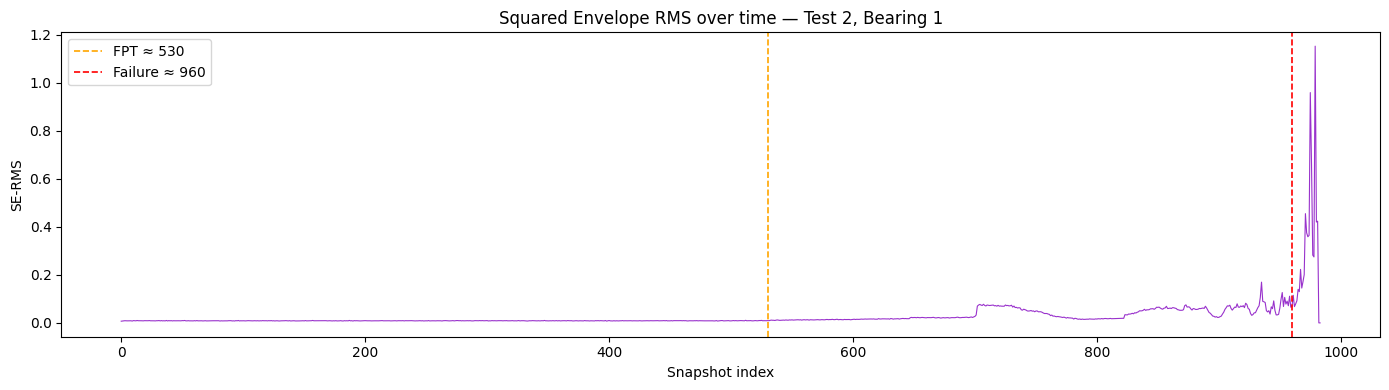

In [170]:
se_rms = np.array([
    np.sqrt(np.mean(compute_envelope(signals[i, :, 0], FS)[2] ** 2))
    for i in range(len(signals))
])

plt.figure(figsize=(14, 4))
plt.plot(se_rms, linewidth=0.8, color="darkorchid")
plt.axvline(x=530, color="orange", linewidth=1.2, linestyle="--", label="FPT ≈ 530")
plt.axvline(x=960, color="red",    linewidth=1.2, linestyle="--", label="Failure ≈ 960")
plt.title("Squared Envelope RMS over time — Test 2, Bearing 1")
plt.xlabel("Snapshot index")
plt.ylabel("SE-RMS")
plt.legend()
plt.tight_layout()
plt.show()